# HW 14 - Astropy
ULAB - Physics and Astronomy Division \
Due **Sunday, March 1st, 2025 at 11:59pm** on Gradescope

## 1 Unit Conversion
Import the astropy module `units` as `u` in the cell below.

In [1]:
import astropy.units as u


Convert a speed of **60 km/h** to **m/s**. \
\
Round your answer to two significant digits. *Hint: With an f-string, you can use `:.3f`, like `print(f"{speed_mps:.3f}")`*.

In [2]:
import astropy.units as u


speed_kmh = 60 * u.km / u.h


speed_mps = speed_kmh.to(u.m / u.s)


print(f"{speed_mps:.2g}")


17 m / s


## 2 Time Manipulation
Define **Julian Date** in the cell below.

In [ ]:
# The continuous count of days from the julian period 

What's the difference between the **Julian calendar** and the **Gregorian calendar**?

In [ ]:
# The Julian calendar adds a date every four years, the Gregorian does the same except in years divisible by 100

From the astropy module `time` import `Time` in the cell below.

In [3]:
from astropy.time import Time

Find the Julian Date for **the current time**. 

In [4]:
from astropy.time import Time

# Get the current time
current_time = Time.now()

# Print the Julian Date
print(f"Julian Date: {current_time.jd}")


Julian Date: 2460744.752120783


Convert `1969-07-02 20:17:00` to its **Julian Date**.

In [5]:
from astropy.time import Time

# Define the date and time
date = Time("1969-07-02 20:17:00")

# Print the Julian Date
print(f"Julian Date: {date.jd}")


Julian Date: 2440405.345138889


What historically happened at this date and time?

In [ ]:
# The moon landing?

## 3 Coordinate Transformations
From the astropy module `coordinates` import `SkyCoord`, `Galactic`, `AltAz` and `EarthLocation` in the cell below.

In [6]:
from astropy.coordinates import SkyCoord, Galactic, AltAz, EarthLocation

Define a celestial object at **RA = 15 degrees** and **DEC = -20 degrees** in ICRS. Use the astropy `Time` module.

In [7]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.time import Time

# Define the celestial object in ICRS
obj = SkyCoord(ra=15 * u.deg, dec=-20 * u.deg, frame='icrs')

# Get the current time
current_time = Time.now()

# Print the object's coordinates and time
print(f"Object Coordinates (ICRS): {obj}")
print(f"Current Time (UTC): {current_time.iso}")


Object Coordinates (ICRS): <SkyCoord (ICRS): (ra, dec) in deg
    (15., -20.)>
Current Time (UTC): 2025-03-10 06:06:21.357


Convert the object's coordinates from ICSRS to **Galactic**.

In [8]:
from astropy.coordinates import SkyCoord
import astropy.units as u

# Define the celestial object in ICRS
obj_icrs = SkyCoord(ra=15 * u.deg, dec=-20 * u.deg, frame='icrs')

# Convert to Galactic coordinates
obj_galactic = obj_icrs.transform_to('galactic')

# Print the converted coordinates
print(f"Galactic Coordinates: l = {obj_galactic.l:.2f}, b = {obj_galactic.b:.2f}")


Galactic Coordinates: l = 138.76 deg, b = -82.61 deg


Convert the object's coordinate from ICRS to **AltAz**. For AltAz frame, use the location of **Campbell Hall**.

In [9]:
from astropy.coordinates import SkyCoord, AltAz, EarthLocation
import astropy.units as u
from astropy.time import Time

# Define the celestial object in ICRS
obj_icrs = SkyCoord(ra=15 * u.deg, dec=-20 * u.deg, frame='icrs')

# Define observer's location (Campbell Hall, UC Berkeley)
berkeley = EarthLocation(lat=37.8732 * u.deg, lon=-122.2573 * u.deg, height=89 * u.m)

# Get the current time
current_time = Time.now()

# Define the AltAz frame with the observer's location and time
altaz_frame = AltAz(obstime=current_time, location=berkeley)

# Convert to AltAz coordinates
obj_altaz = obj_icrs.transform_to(altaz_frame)

# Print the converted coordinates
print(f"AltAz Coordinates: Altitude = {obj_altaz.alt:.2f}, Azimuth = {obj_altaz.az:.2f}")


AltAz Coordinates: Altitude = -37.38 deg, Azimuth = 273.00 deg


## 4 FITS Files
From the astropy module `astropy.io` import `fits` in the cell below.

In [10]:
from astropy.io import fits

From the astropy module `astropy.utils.data` import `download_file`.

In [13]:
from astropy.utils.data import download_file

Import `numpy` in the cell below.

In [ ]:
import numpy as np

Use the `download_file` astropy function to create a variable for the location of the `.fits` file from class.

In [14]:
from astropy.utils.data import download_file


url = 'http://data.astropy.org/tutorials/FITS-images/HorseHead.fits'

fits_file_path = download_file(url, cache=True)

print(f"FITS file downloaded to: {fits_file_path}")


FITS file downloaded to: /Users/thomas/.astropy/cache/download/url/ff6e0b93871033c68022ca026a956d87/contents


Follow the procedure from lecture to open the `.fits` files in the cell below. Make sure to use the `hdul` format, while calling `hdul.info`, `hdul[0]` and `hdul[1]` appropriately.

In [18]:

url = 'http://data.astropy.org/tutorials/FITS-images/HorseHead.fits'
fits_file_path = download_file(url, cache=True)

hdul = fits.open(fits_file_path)

hdul.info()

primary_hdu = hdul[0]
print("\nPrimary HDU Header:")
print(primary_hdu.header)

if len(hdul) > 1:
    secondary_hdu = hdul[1]
    print("\nSecondary HDU Data:")
    print(secondary_hdu.data)

hdul.close()


Filename: /Users/thomas/.astropy/cache/download/url/ff6e0b93871033c68022ca026a956d87/contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   (891, 893)   int16   
  1  er.mask       1 TableHDU        25   1600R x 4C   [F6.2, F6.2, F6.2, F6.2]   

Primary HDU Header:
SIMPLE  =                    T /FITS: Compliance                                BITPIX  =                   16 /FITS: I*2 Data                                  NAXIS   =                    2 /FITS: 2-D Image Data                            NAXIS1  =                  891 /FITS: X Dimension                               NAXIS2  =                  893 /FITS: Y Dimension                               EXTEND  =                    T /FITS: File can contain extensions               DATE    = '2014-01-09        '  /FITS: Creation Date                            ORIGIN  = 'STScI/MAST'         /GSSS: STScI Digitized Sky Survey                SURVEY  = 'SERC-ER '           /GSSS

With the `np.max` function, find the brightest pixel in the image. Print its value in the cell below.

In [17]:

url = 'http://data.astropy.org/tutorials/FITS-images/HorseHead.fits'
fits_file_path = download_file(url, cache=True)

with fits.open(fits_file_path) as hdul:
    image_data = hdul[0].data  # Access the image data

brightest_pixel = np.max(image_data)

print(f"Brightest pixel value: {brightest_pixel}")


Brightest pixel value: 22918


With the `np.min` function, find the least brightest pixel in the image. Print its value in the cell below.

In [19]:
# Assuming this meant least bright
url = 'http://data.astropy.org/tutorials/FITS-images/HorseHead.fits'
fits_file_path = download_file(url, cache=True)

with fits.open(fits_file_path) as hdul:
    image_data = hdul[0].data  # Access the image data

least_bright_pixel = np.min(image_data)

print(f"Least bright pixel value: {least_bright_pixel}")


Least bright pixel value: 3759


## Tables
From the astropy module `astropy.table` import `Table`.

In [20]:
from astropy.table import Table

Make an astropy table with **three** actual stars (so you will need to use google for this part). Include the `name`, `magnitude` and `spectral type`.

In [21]:

stars = {
    "Name": ["Sirius", "Betelgeuse", "Vega"],
    "Magnitude": [-1.46, 0.42, 0.03],  # Apparent magnitude
    "Spectral Type": ["A1V", "M1-2Ia-Iab", "A0V"]
}

# Create the table
star_table = Table(stars)

# Print the table
print(star_table)


   Name    Magnitude Spectral Type
---------- --------- -------------
    Sirius     -1.46           A1V
Betelgeuse      0.42    M1-2Ia-Iab
      Vega      0.03           A0V


Save the table as a `.fits` file. *Hint: Use the function `.write` with the argument `format='fits'`.*

In [22]:

stars = {
    "Name": ["Sirius", "Betelgeuse", "Vega"],
    "Magnitude": [-1.46, 0.42, 0.03],  # Apparent magnitude
    "Spectral Type": ["A1V", "M1-2Ia-Iab", "A0V"]
}

star_table = Table(stars)

star_table.write("stars_table.fits", format="fits", overwrite=True)

print("Table saved as 'stars_table.fits'")


Table saved as 'stars_table.fits'


Read and print the table in the cell below from the `.fits` file you made.

In [23]:

# Read the table from the FITS file
star_table = Table.read("stars_table.fits", format="fits")

# Print the table
print(star_table)


   Name    Magnitude Spectral Type
---------- --------- -------------
    Sirius     -1.46           A1V
Betelgeuse      0.42    M1-2Ia-Iab
      Vega      0.03           A0V


## 6 Advanced... but awesome!
With the Hipparcos catalog, construct a Hertzsprung-Russell (H-R) diagram. Overall you will do the following:
* Download and clean the stellar data from the Hipparcos catalog.
* Calculate the absolute magnitude of the stars.
* Convert and classify spectral types.
* Plot an H-R diagram using both spectral class and color-index (B-V).

In the cell below, define what an **H-R** diagram is.

In [ ]:
#A Hertzsprung-Russell (H-R) diagram is a scatter plot that shows the relationship between the absolute magnitude (or luminosity) of 
#stars and their surface temperature (or spectral classification). It is a fundamental tool in astrophysics for understanding stellar 
#evolution.


### 6.1 Download and Load in the Hipparcos Catalog
The catalog you are downloading contains accurate parallax measurements which will help us determine the **absolute magnitude** of stars. 
* **Absolute mangitude** = the actual brightness of a star
* **Apparent magnitude** = how bright the star appears to us on Earth

Import `pandas` in the cell below.

In [26]:
import pandas as pan

In the cell below import the file `cluster_data.csv` as a pandas dataframe. Add the following arguments:
* skiprows=44
* sep=';'
* header=None
* index_col=0
* names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType']
* skipfooter=1
* engine='python'

In [27]:


# Load the CSV file with specified parameters
df = pan.read_csv("cluster_data.tsv", 
                 skiprows=44, 
                 sep=';', 
                 header=None, 
                 index_col=0, 
                 names=['HIP', 'Vmag', 'Plx', 'B-V', 'SpType'], 
                 skipfooter=1, 
                 engine='python')

print(df.head())


      Vmag      Plx     B-V SpType
HIP                               
10    8.59    10.76   0.489    F6V
11    7.34     4.29   0.081     A2
12    8.43     4.06   1.484  K4III
13    8.80     3.49   1.128  K0III
14    7.25     5.11   1.200     K0


Display the first few rows of the data.

In [29]:

# Load the CSV file with specified parameters
df = pan.read_csv("cluster_data.tsv", 
                 skiprows=44, 
                 sep=';', 
                 header=None, 
                 index_col=0, 
                 names=['HIP', 'Vmag', 'Plx', 'B-V', 'SpType'], 
                 skipfooter=1, 
                 engine='python')

print(df.head())


      Vmag      Plx     B-V SpType
HIP                               
10    8.59    10.76   0.489    F6V
11    7.34     4.29   0.081     A2
12    8.43     4.06   1.484  K4III
13    8.80     3.49   1.128  K0III
14    7.25     5.11   1.200     K0


### 6.2 Clean the Data
Some of the rows in the data contain **missing** or **invalid** values so we need to "clean" our data. We will start by replacing the **blank spaces with NaN**, run the cell below.

In [38]:
df_cleans = df.map(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)

Drop the rows with missing (NaN) values. *Hint: Use the `.dropna()` function`.

In [34]:
# Drop rows with missing values
df_cleaned = df.dropna()

# Display the first few rows of the cleaned DataFrame
print(df_cleaned.head())


      Vmag      Plx     B-V SpType
HIP                               
10    8.59    10.76   0.489    F6V
11    7.34     4.29   0.081     A2
12    8.43     4.06   1.484  K4III
13    8.80     3.49   1.128  K0III
14    7.25     5.11   1.200     K0


Run the cell below. We are converting the datatypes in the columns to floats.

In [35]:
df_clean[['Vmag', 'Plx', 'B-V']] = df_clean[['Vmag', 'Plx', 'B-V']].astype(float)

# Display dataset summary
print(df_clean.describe())

                Vmag            Plx            B-V
count  118208.000000  117946.000000  116928.000000
mean        8.373183       7.215046       0.706391
std         1.312023      11.286330       0.489828
min        -1.440000     -54.950000      -0.400000
25%         7.640000       2.510000       0.347000
50%         8.440000       4.610000       0.612000
75%         9.150000       8.410000       1.078000
max        14.080000     772.330000       5.460000


### 6.3 Compute Absolute Magnitude
The absolute magnitude ($M_V$) of a star is given by:

$$
M_V = V_{\text{mag}} + 5 \cdot \log_{10}\left(\frac{\text{Plx}}{100}\right)
$$

Run the cell below.

In [36]:
df_clean['M_V'] = df_clean['Vmag'] + 5 * np.log10(df_clean['Plx'] / 100)
print(df_clean[['Vmag', 'Plx', 'M_V']].head())

     Vmag    Plx       M_V
HIP                       
10   8.59  10.76  3.749061
11   7.34   4.29  0.502286
12   8.43   4.06  1.472630
13   8.80   3.49  1.514127
14   7.25   5.11  0.792105


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Describe what the cell above is doing. 

In [ ]:
# Calculating the absolute magnitude of the stars and adding them to the table

### 6.4 Process the Spectral Types
Stars are defined by their spectral types:
* The first letter (O, B, A, F, G, K, M) indicates the **temperature** of a star.
* The digit (0-9) refines the **classification**.

Now we will extract the first two characters for sorting purposes. Run the cell below.

In [41]:
# Extract the first two characters (e.g., 'G2', 'K3')
df_clean['SpType2'] = df_clean['SpType'].str[:2]

# Remove rows where 'SpType2' is NaN
df_clean = df_clean.dropna(subset=['SpType2'])

# Keep only valid spectral classes
df_clean = df_clean[df_clean['SpType2'].str.match(r'^[OBAFGKM][0-9]')]

# Display unique spectral types
print(df_clean['SpType2'].unique())


['F6' 'A2' 'K4' 'K0' 'K2' 'F3' 'K5' 'G5' 'G0' 'G8' 'F2' 'G3' 'F7' 'A0'
 'B8' 'F0' 'G6' 'G9' 'K1' 'K3' 'F5' 'G1' 'A4' 'G2' 'B5' 'B9' 'M0' 'F8'
 'M1' 'G7' 'M2' 'B0' 'B7' 'A9' 'M3' 'A3' 'O7' 'A1' 'B4' 'A6' 'B3' 'B2'
 'A5' 'M4' 'A7' 'O8' 'F1' 'M5' 'G4' 'K7' 'B1' 'O6' 'M6' 'F4' 'A8' 'K8'
 'M7' 'B6' 'O9' 'F9' 'M8' 'M9' 'K9' 'O5' 'K6' 'O4']


What letter represents the **hottest** stars? What letter represents the **coldest** stars?

In [ ]:
# O, M

### 6.5 Plot the H-R Diagram(s)
Conver the spectral types into sortable numerical categories. Run the cell below.

In [42]:
order = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
df_clean['SpType2_numeric'] = df_clean['SpType2'].apply(lambda x: order[x[0]]*10 + int(x[1]))

Import `matplotlib.pyplot` in the cell below.

In [43]:
import matplotlib.pyplot as plt

**Spectral Type vs. Absolute Magnitude** \
Scatter the `df_clean['SpType2_numeric']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(0, 70).
* Set a `ylim` of `(15, -10).
* Call `xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])`.
* Call `xticks(range(5,75,10))`.
* Title the x-axis `'Spectral Type'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

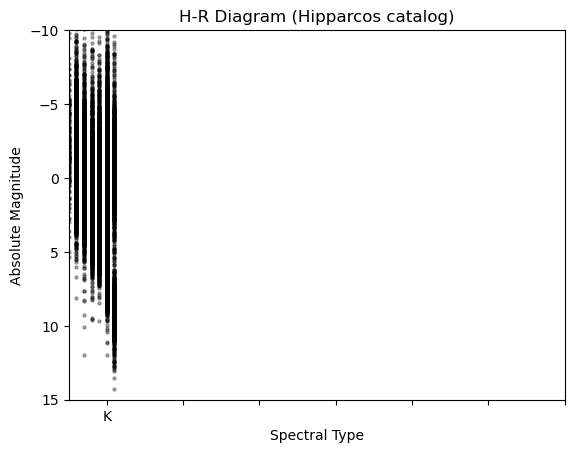

In [44]:

# Convert SpType2 to a numeric scale (O=0, B=1, A=2, F=3, G=4, K=5, M=6)
spectral_mapping = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
df_clean['SpType2_numeric'] = df_clean['SpType2'].str[0].map(spectral_mapping)

plt.scatter(df_clean['SpType2_numeric'], df_clean['M_V'], s=5, alpha=0.3, c='k')

# Set the axis limits
plt.xlim(0, 7)  # Since there are 7 spectral types from O to M
plt.ylim(15, -10)  # Set the limits for Absolute Magnitude

# Set the x-axis labels and ticks
plt.xticks(range(0, 7), ['O', 'B', 'A', 'F', 'G', 'K', 'M'])
plt.xticks(range(5, 75, 10))

# Title and axis labels
plt.title("H-R Diagram (Hipparcos catalog)")
plt.xlabel("Spectral Type")
plt.ylabel("Absolute Magnitude")

# Show the plot
plt.show()


**Color Index (B-V) vs. Absolute Magnitude** \
Scatter the `df_clean['B-V']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(-0.5, 2.5).
* Set a `ylim` of `(15, -10).
* Title the x-axis `'Color Index (B-V)'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

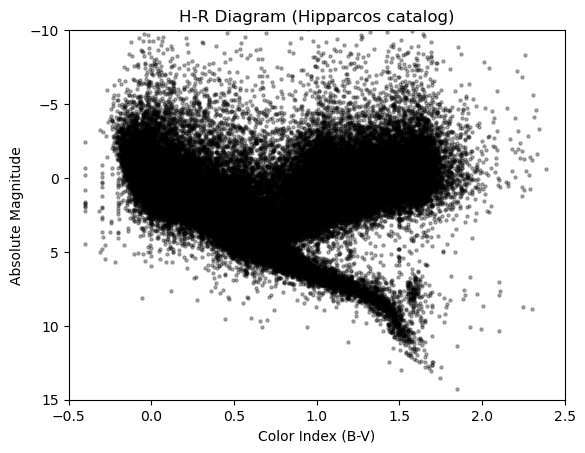

In [45]:

# Create the scatter plot
plt.scatter(df_clean['B-V'], df_clean['M_V'], s=5, alpha=0.3, c='k')

# Set the axis limits
plt.xlim(-0.5, 2.5)  # Color index (B-V) range
plt.ylim(15, -10)    # Set the limits for Absolute Magnitude

# Titles and axis labels
plt.title("H-R Diagram (Hipparcos catalog)")
plt.xlabel("Color Index (B-V)")
plt.ylabel("Absolute Magnitude")

# Show the plot
plt.show()


### 6.6 Highlight Luminosity Classes
Great! Finally, we want to difference between our three main luminosity classes:
* Main Sequence (V), aka what our sun is
* Giants (III)
* Supergiants(I)

Run the cell below.

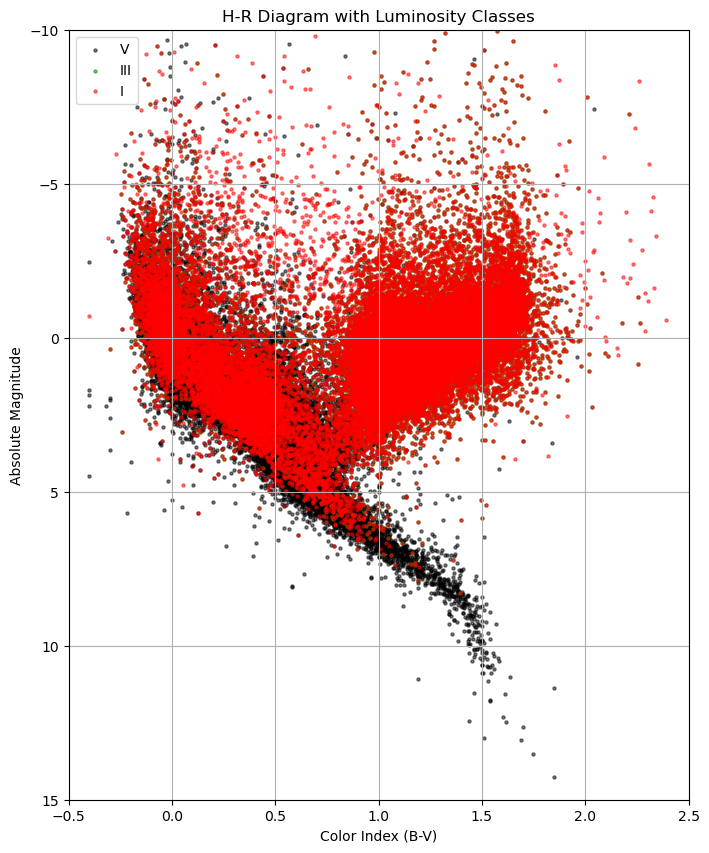

In [46]:
def plot_luminosity_class(df, label, color):
    mask = df['SpType'].str.contains(label, na=False)
    plt.scatter(df[mask]['B-V'], df[mask]['M_V'], s=5, label=label, c=color, alpha=0.5)

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants

plt.legend()
plt.show()


With the example above, now plot the following types **WITH** and then **WITHOUT** the ones above:
* Subdwarfs (VI)
* White dwarfs (VII)
* Subgiants (IV)
* Bright giants (II)

/var/folders/dm/wd5k1xdn5yv3lq9vgtz_qd3c0000gn/T/ipykernel_57861/4070150398.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  stellar_types_excluded = df_clean[~df_clean['SpType'].str.contains(r'(VI|VII|IV|II)', na=False)]


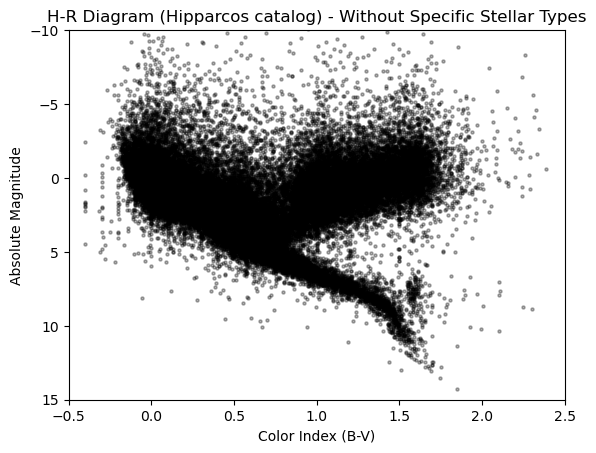

In [47]:
# Filter out the specified stellar types
stellar_types_excluded = df_clean[~df_clean['SpType'].str.contains(r'(VI|VII|IV|II)', na=False)]

# Create the scatter plot without the specified stellar types
plt.scatter(stellar_types_excluded['B-V'], stellar_types_excluded['M_V'], s=5, alpha=0.3, c='k')

# Set the axis limits
plt.xlim(-0.5, 2.5)  # Color index (B-V) range
plt.ylim(15, -10)    # Set the limits for Absolute Magnitude

# Titles and axis labels
plt.title("H-R Diagram (Hipparcos catalog) - Without Specific Stellar Types")
plt.xlabel("Color Index (B-V)")
plt.ylabel("Absolute Magnitude")

# Show the plot
plt.show()


/var/folders/dm/wd5k1xdn5yv3lq9vgtz_qd3c0000gn/T/ipykernel_57861/1502666705.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  stellar_types_included = df_clean[df_clean['SpType'].str.contains(r'(VI|VII|IV|II)', na=False)]


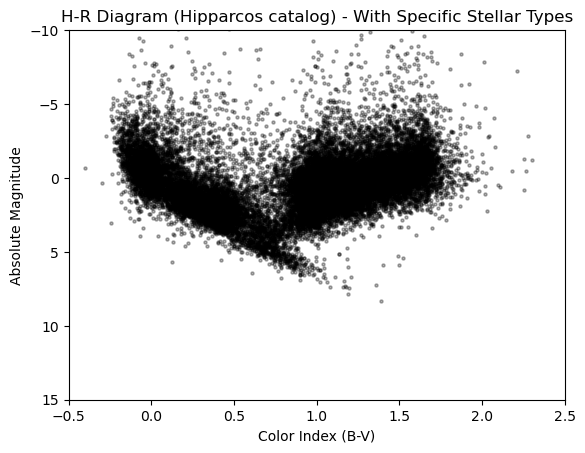

In [48]:

# Filter for the specified stellar types
stellar_types_included = df_clean[df_clean['SpType'].str.contains(r'(VI|VII|IV|II)', na=False)]

# Create the scatter plot with the specified stellar types
plt.scatter(stellar_types_included['B-V'], stellar_types_included['M_V'], s=5, alpha=0.3, c='k')

# Set the axis limits
plt.xlim(-0.5, 2.5)  # Color index (B-V) range
plt.ylim(15, -10)    # Set the limits for Absolute Magnitude

# Titles and axis labels
plt.title("H-R Diagram (Hipparcos catalog) - With Specific Stellar Types")
plt.xlabel("Color Index (B-V)")
plt.ylabel("Absolute Magnitude")

# Show the plot
plt.show()


Submit your FITS file and this notebook to Gradescope!